# Demo 2 — An image really is just numbers

_Section 2: How Images Are Represented._

We'll open a photo in code, reveal that it's just a big table of numbers, zoom into a single pixel, and print its **(R, G, B)** values live — watching a picture turn into a grid of numbers.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = "demo.jpg"  # the shared image used across all demos

## 1. Open the photo

OpenCV reads images as **BGR**, so we convert to **RGB** for display.

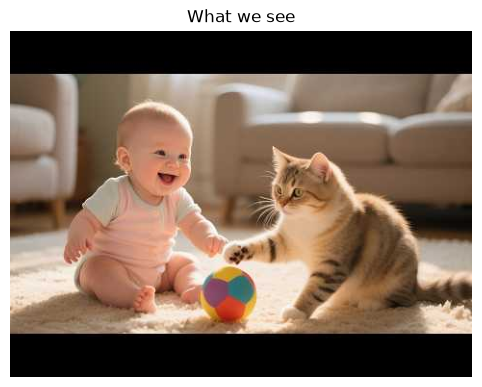

In [2]:
bgr = cv2.imread(IMG_PATH)              # OpenCV loads as BGR
img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)  # -> RGB

plt.figure(figsize=(6, 4.5))
plt.imshow(img)
plt.axis("off")
plt.title("What we see")
plt.show()

## 2. What the computer sees: an array of numbers

The image is just a NumPy array of shape `(height, width, 3)`.

In [3]:
print("type :", type(img))
print("shape:", img.shape, " (height, width, channels)")
print("dtype:", img.dtype, " (each number is 0-255)")

h, w, c = img.shape
print(f"\nThat's {h} x {w} x {c} = {h * w * c:,} numbers in this one picture.")

# A raw peek at the numbers themselves: a 3x4 block of pixels on the ball.
np.set_printoptions(linewidth=100)
print("\nA 3x4 block of pixels on the ball (each entry is one [R, G, B] pixel):\n")
print(img[291:294, 224:228])

type : <class 'numpy.ndarray'>
shape: (360, 480, 3)  (height, width, channels)
dtype: uint8  (each number is 0-255)

That's 360 x 480 x 3 = 518,400 numbers in this one picture.

A 3x4 block of pixels on the ball (each entry is one [R, G, B] pixel):

[[[192  48  24]
  [192  48  22]
  [193  49  25]
  [195  51  25]]

 [[190  43  23]
  [190  44  21]
  [191  44  24]
  [193  47  24]]

 [[188  38  21]
  [189  39  22]
  [190  40  23]
  [192  43  23]]]


## 3. Zoom into a patch

Let's crop a small region around the ball. Slicing the array `[y0:y1, x0:x1]` cuts out a rectangle of pixels.

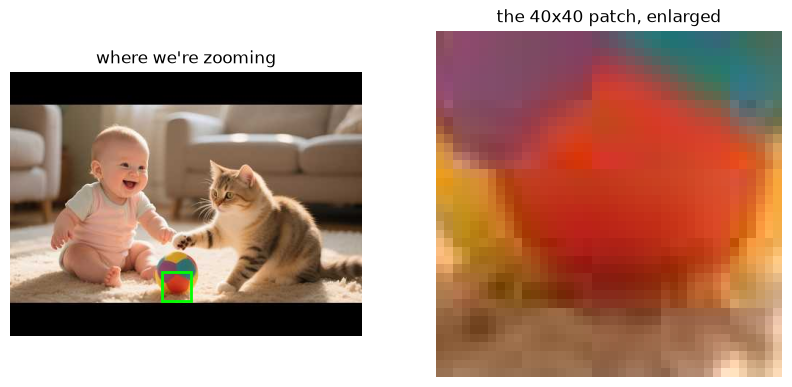

In [4]:
# Region around the colorful ball (row range, col range)
y0, y1 = 272, 312
x0, x1 = 206, 246
patch = img[y0:y1, x0:x1]

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
ax[0].imshow(img)
ax[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                              edgecolor="lime", facecolor="none", lw=2))
ax[0].axis("off")
ax[0].set_title("where we're zooming")

ax[1].imshow(patch, interpolation="nearest")
ax[1].set_title(f"the {patch.shape[0]}x{patch.shape[1]} patch, enlarged")
ax[1].axis("off")
plt.show()

## 4. Zoom in further: each square is a pixel, each pixel is 3 numbers

Take a tiny patch and print the (R, G, B) triple sitting inside every pixel.

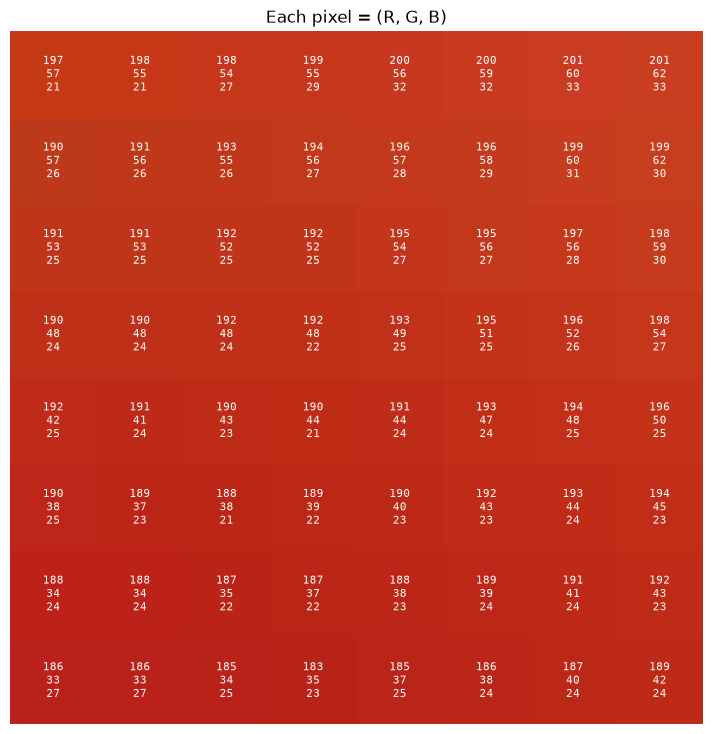

In [5]:
ty0, ty1 = 288, 296
tx0, tx1 = 222, 230
tiny = img[ty0:ty1, tx0:tx1]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(tiny, interpolation="nearest")
for i in range(tiny.shape[0]):
    for j in range(tiny.shape[1]):
        r, g, b = (int(v) for v in tiny[i, j])
        color = "white" if (r + g + b) < 384 else "black"
        ax.text(j, i, f"{r}\n{g}\n{b}", ha="center", va="center",
                color=color, fontsize=8, fontfamily="monospace")
ax.set_title("Each pixel = (R, G, B)")
ax.axis("off")
plt.show()

## 5. Print a single pixel's value

The heart of the demo: one pixel is just three numbers.

In [6]:
row, col = 292, 226  # a point on the ball
r, g, b = (int(v) for v in img[row, col])

print(f"Pixel at (row={row}, col={col}):")
print(f"  R = {r}")
print(f"  G = {g}")
print(f"  B = {b}")
print(f"\n  => (R, G, B) = ({r}, {g}, {b})")

Pixel at (row=292, col=226):
  R = 191
  G = 44
  B = 24

  => (R, G, B) = (191, 44, 24)


## 6. Grayscale: one number per pixel (0-255)

Drop color and each pixel becomes a single brightness value: `0` = black, `255` = white.

grayscale shape: (360, 480) -> just one number per pixel


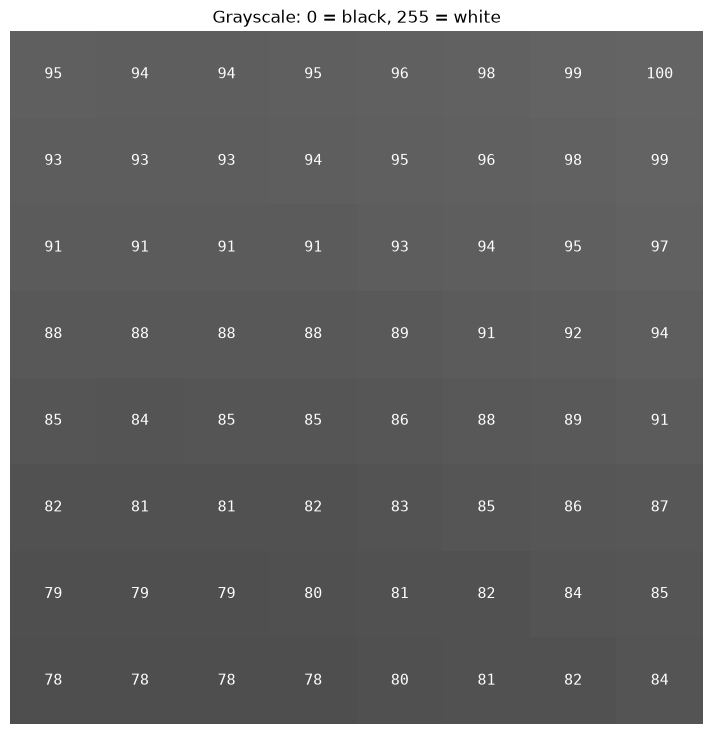

In [7]:
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
print("grayscale shape:", gray.shape, "-> just one number per pixel")

gtiny = gray[ty0:ty1, tx0:tx1]
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(gtiny, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
for i in range(gtiny.shape[0]):
    for j in range(gtiny.shape[1]):
        v = int(gtiny[i, j])
        color = "white" if v < 128 else "black"
        ax.text(j, i, str(v), ha="center", va="center",
                color=color, fontsize=11, fontfamily="monospace")
ax.set_title("Grayscale: 0 = black, 255 = white")
ax.axis("off")
plt.show()

## Takeaway

The computer never "sees" a baby, a cat, or a ball — it only has this **grid of numbers**. Everything in the rest of the talk is just math on this grid.